# Assignment 1 2AMM10 2025-2026

## Group: [Name Editing]
### Member 1: [Chang Qin]
### Member 2: [Annebel Hattingh-Haasbroek]
### Member 3: [Alexandru Vasu]

In [1]:
import os
import re
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import kagglehub
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from sklearn.metrics import confusion_matrix
from itertools import combinations
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data.sampler import BatchSampler
from torch.utils.data import DataLoader

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

C:\Users\20223084\.conda\envs\dl_code\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


True
NVIDIA RTX A2000 Laptop GPU


In [2]:
# Boolean values to indicate retraining / loading / evaluation needs
# Allowed for easier and faster "kernel restart and run all cells"
train_task1 = False  
infer_task1 = False  # change to True for submission run

train_task2 = False
infer_task2 = False  # change to True for submission run

train_task3 = False  
infer_task3 = False  # change to True for submission run

train_task4 = True

## Task 1

Dataset and visualization

In [3]:
class AppleDataset(Dataset):
    def __init__(self, transform=None, subset="train",class_subset = "main"):
        assert subset in ["train","test"]
        assert class_subset in ["main","new","all"]
        path = kagglehub.dataset_download("moltean/fruits")
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        all_folders = sorted(os.listdir(self.path))
        self.item_folders = sorted(x for x in all_folders if x.lower().startswith("apple"))
        generator=np.random.default_rng(6)
        generator.shuffle(self.item_folders)
        if class_subset == "main":
            self.item_folders = self.item_folders[:20]
        elif class_subset == "new":
            self.item_folders = self.item_folders[20:]
        self.targets = []
        self.image_paths = []
        for i, folder in enumerate(self.item_folders):
            for img_file in sorted(os.listdir(self.path / folder)):
                if img_file.startswith("r0"):
                    if class_subset=="new":
                        self.targets.append(i+20)
                    else:
                        self.targets.append(i)
                    self.image_paths.append(self.path / folder / img_file)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, i):
        image = Image.open(self.image_paths[i]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.targets[i]

dataset = AppleDataset()

item_dd = widgets.Dropdown(options=dataset.item_folders, description="Variety:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(folder):
    return sorted(f for f in os.listdir(dataset.path / folder)
                  if f.startswith("r0_") and f.endswith(".jpg"))

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

# item_dd.observe(update_slider, names="value")
# frame_slider.observe(show_image, names="value")

# update_slider()
# display(widgets.VBox([item_dd, frame_slider, output]))

In [4]:
# Transformations for the Tasks
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data = AppleDataset(subset="train",transform=transform)
test_data = AppleDataset(subset="test",transform=transform)
support_new_data = AppleDataset(subset="train",transform=transform,class_subset="new")
test_new_data = AppleDataset(subset="test",transform=transform,class_subset="new")

# your code here

In [5]:
# This code is taken from Practical P2.2.
class BalancedBatchSampler(BatchSampler):
    """
    Returns batches of size n_classes * n_samples
    """

    def __init__(self, labels, n_classes, n_samples):
        self.labels = np.array(labels)
        self.labels_set = list(set(self.labels))
        self.label_to_indices = {label: np.where(self.labels == label)[0]
                                 for label in self.labels_set}
        for l in self.labels_set:
            np.random.shuffle(self.label_to_indices[l])
        self.used_label_indices_count = {label: 0 for label in self.labels_set}
        self.count = 0
        self.n_classes = n_classes
        self.n_samples = n_samples
        self.n_dataset = len(self.labels)
        self.batch_size = self.n_samples * self.n_classes

    def __iter__(self):
        self.count = 0
        while self.count + self.batch_size < self.n_dataset:
            classes = np.random.choice(self.labels_set, self.n_classes, replace=False)
            indices = []
            for class_ in classes:
                indices.extend(self.label_to_indices[class_][
                               self.used_label_indices_count[class_]:self.used_label_indices_count[
                                                                         class_] + self.n_samples])
                self.used_label_indices_count[class_] += self.n_samples
                if self.used_label_indices_count[class_] + self.n_samples > len(self.label_to_indices[class_]):
                    np.random.shuffle(self.label_to_indices[class_])
                    self.used_label_indices_count[class_] = 0
            yield indices
            self.count += self.n_classes * self.n_samples

    def __len__(self):
        return self.n_dataset // self.batch_size

In [6]:
train_batch_sampler = BalancedBatchSampler(train_data.targets, n_classes=10, n_samples=25)
test_batch_sampler = BalancedBatchSampler(test_data.targets, n_classes=10, n_samples=25)

triplets_train_loader = DataLoader(train_data, batch_sampler=train_batch_sampler)
triplets_test_loader = DataLoader(test_data, batch_sampler=test_batch_sampler)

In [7]:
# Training done using Triplet Loss with hard negatives
class BatchHardTripletLoss(nn.Module):
    def __init__(self, margin):
        super().__init__()
        self.margin = margin

    def forward(self, embeddings, labels):
        # Pair-wise distance matrix using cosine similarity
        # Assumes embeddings are L2-normalized
        dist = 1 - torch.matmul(embeddings, embeddings.T)

        labels = labels.unsqueeze(1)

        # Masks for negatives and positives
        pos_mask = labels == labels.T
        neg_mask = labels != labels.T

        # Remove self comparisons (diagonal entries)
        eye = torch.eye(len(labels), device=labels.device).bool()
        pos_mask = pos_mask & (~eye)

        # positive: Farthest sample from same class
        hardest_pos = (dist * pos_mask.float()).max(dim=1).values

        # negative: Closest sample of different class
        max_dist = dist.max()
        dist_neg = dist + (~neg_mask).float() * max_dist
        hardest_neg = dist_neg.min(dim=1).values

        # Enforce max(0, pos - neg + margin)
        loss = F.relu(hardest_pos - hardest_neg + self.margin)

        return loss.mean()

In [8]:
# This code is adapted from the Practical P2.2.
# The EmbeddingNet class is inspired by one of our solutions to P2.2.
class EmbeddingNet(nn.Module):
    def __init__(self):
        """Build our CNN embedding."""
        super(EmbeddingNet, self).__init__()

        self.layer1 = nn.Sequential(
            ## Block 1
            # Takes 3 color channels as with 32 filters and kernel size 3x3
            # output (32, 32, 128, 128)
            nn.Conv2d(3, 32, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # Takes max value in each 2x2 region
            # output (32, 32, 64, 64)
            nn.MaxPool2d(2),

            ## Block 2
            # output (32, 64, 64, 64)
            nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            # output (32, 64, 32, 32)
            nn.MaxPool2d(2),

            ## Block 3
            # output (32, 128, 32, 32)
            nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            # output (32, 128, 16, 16)
            nn.MaxPool2d(2),

            ## Block 4
            # output (32, 256, 16, 16)
            nn.Conv2d(128, 256, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            # output (32, 256, 8, 8)
            nn.MaxPool2d(2),
        )

        # Compress each feature map into a single number
        # output (32, 256, 1, 1)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # Compress learned features to original image size
        # output (32, 128)
        self.embedding = nn.Linear(256, 128)

    def forward(self, x):
        x = self.layer1(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.embedding(x)
        x = F.normalize(x, dim=1)
        return x

    def get_embedding(self, x):
        return self.forward(x)

In [9]:
# This code is taken from Practical P2.2.
class Trainer():
    def __init__(self,
                 model: torch.nn.Module,
                 device: torch.device,
                 criterion: torch.nn.Module,
                 optimizer: torch.optim.Optimizer,
                 training_DataLoader: torch.utils.data.Dataset,
                 validation_DataLoader: torch.utils.data.Dataset,
                 epochs: int,
                 criterion_validation: torch.nn.Module = None,
                 ):

        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.training_DataLoader = training_DataLoader
        self.validation_DataLoader = validation_DataLoader
        self.device = device
        self.epochs = epochs

        if criterion_validation is None:
            self.criterion_validation = criterion
        else: 
            self.criterion_validation = criterion_validation

    def run_trainer(self):
        # Train and validate with loading bar
        for epoch in tqdm(range(self.epochs)):
            # Training
            self.model.train()
            train_losses=[]

            for batch in self.training_DataLoader:
                x, y = batch
                input, target = x.to(self.device), y.to(self.device)
                self.optimizer.zero_grad()
                out = self.model(input)
                loss = self.criterion(out, target)

                loss_value = loss.item()
                train_losses.append(loss_value)

                loss.backward()
                self.optimizer.step()

            # Validation
            self.model.eval()
            valid_losses = []

            for batch in self.validation_DataLoader:
                x ,y = batch
                input, target = x.to(self.device), y.to(self.device)

                with torch.no_grad():
                    out = self.model(input)
                    loss = self.criterion_validation(out, target)

                    loss_value = loss.item()
                    valid_losses.append(loss_value)

            print(
                f'EPOCH: {epoch+1:0>{len(str(self.epochs))}}/{self.epochs}',
                end=' '
            )
            print(f'LOSS: {np.mean(train_losses):.4f}',end=' ')
            print(f'VAL-LOSS: {np.mean(valid_losses):.4f}',end='\n')

In [10]:
# This code is taken from Practical P2.2.

# Move away from CPU for faster training if possible
if torch.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device=torch.device('cuda')
else:
    device=torch.device('cpu')
print(f"Training on {device}")

embedding_net = EmbeddingNet()
model = embedding_net.to(device)

margin=1

criterion = BatchHardTripletLoss(margin)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

Training on cuda


In [11]:
# Train
trainer = Trainer(model=model,
                  device=device,
                  criterion=criterion,
                  optimizer=optimizer,
                  training_DataLoader=triplets_train_loader,
                  validation_DataLoader=triplets_test_loader,
                  epochs=10)

In [12]:
# Boolean to either save new model of load old one
model_path_task1 = "task1_model_weights_hard_v1.pth"
if train_task1:
    trainer.run_trainer()
    torch.save(model.state_dict(), model_path_task1)
    print(f"Saved model to {model_path_task1}")
else:
    model.load_state_dict(torch.load(model_path_task1, weights_only=True))
    model.eval()
    print(f"Loaded model from {model_path_task1}")

Loaded model from task1_model_weights_hard_v1.pth


In [13]:
# Create data loaders for evalution on different sets
train_loader = DataLoader(train_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

support_loader = DataLoader(support_new_data, batch_size=64, shuffle=False)
test_new_loader = DataLoader(test_new_data, batch_size=64, shuffle=False)

In [14]:
# This code is adapted from Practical P2.2.
def extract_embeddings(model, dataloader, device):
    """Function to extract embeddings."""
    embeddings = []
    labels = []

    model.eval()
    with torch.no_grad():
        for images, targets in dataloader:
            images = images.to(device)
            targets = targets.to(device)

            emb = model(images)

            embeddings.append(emb)
            labels.append(targets)

    # Leave CPU conversion for after the for loop for faster extraction
    embeddings = torch.cat(embeddings, dim=0).cpu()
    labels = torch.cat(labels, dim=0).cpu()

    return embeddings, labels

In [15]:
def knn_predict(support_embs, support_lbls, test_embs, k=10):
    """
    kNN used as evaluation metric for models.
    cosine-similarity weighted kNN classifier used on embeddings.
    """
    # Normalize embeddings to unit vectors for cosine similarity calculation
    support_embs = torch.nn.functional.normalize(support_embs, dim=1)
    test_embs = torch.nn.functional.normalize(test_embs, dim=1)

    # Similarity matrix and top-k embeddings with highest cosine similarity
    sims = test_embs @ support_embs.T
    topk = torch.topk(sims, k, dim=1)

    preds = []

    for i in range(test_embs.size(0)):
        # Get neighbor similarities
        # How strong each neighbor matches point i
        neighbor_idxs = topk.indices[i]
        neighbor_labels = support_lbls[neighbor_idxs]
        neighbor_sims = topk.values[i]

        # Get weighted votes per class
        score = defaultdict(float)

        # Similarity-weighted vote over typical majority vote
        for lbl, sim in zip(neighbor_labels, neighbor_sims):
            score[int(lbl.item())] += float(sim)

        preds.append(max(score, key=score.get))

    preds = torch.tensor(preds, device=test_embs.device)
    return preds

In [16]:
# Boolean value to evaluate Task 1 model or not
# To improve time with "restart and run all cells" and for the PDF generation later
if infer_task1:
    # ----- test_data --------
    train_embeddings, train_labels = extract_embeddings(model, train_loader, device)
    test_embeddings, test_labels = extract_embeddings(model, test_loader, device)

    predictions = knn_predict(train_embeddings, train_labels, test_embeddings)
    accuracy = (predictions == test_labels).float().mean()
    
    print("Test Accuracy for test_data:", accuracy.item() * 100)

    # ----- test_new_data --------
    support_embeddings, support_labels = extract_embeddings(model, support_loader, device)
    test_new_embeddings, test_new_labels = extract_embeddings(model, test_new_loader, device)
    
    new_predictions = knn_predict(support_embeddings, support_labels, test_new_embeddings)
    accuracy = (new_predictions == test_new_labels).float().mean()
    
    print("New Test Data Accuracy for test_new_data:", accuracy.item() * 100)

## Task 2

In [17]:
class GardenDataset(Dataset):
    def __init__(self, transform=None, class_level="item", subset="train", family_subset="main", item_subset="main"):
        assert class_level in ["item","family","both"]
        assert subset in ["train","test"]
        assert family_subset in ["main","new","all"]
        assert item_subset in ["main","new","all"]
        path = kagglehub.dataset_download("moltean/fruits")
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        self.class_level = class_level

        canonical_items = sorted(
            d for d in os.listdir(base / "Training")
            if (base / "Training" / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        )
        item_to_family = {it: it.rsplit(' ', 1)[0] for it in canonical_items}
        canonical_families = sorted(set(item_to_family.values()))

        self.item_to_idx = {c: i for i, c in enumerate(canonical_items)}
        self.family_to_idx = {c: i for i, c in enumerate(canonical_families)}

        train_fam_to_items = defaultdict(list)
        for it in canonical_items:
            train_fam_to_items[item_to_family[it]].append(it)
        for fam in train_fam_to_items:
            train_fam_to_items[fam].sort(key=lambda x: int(x.rsplit(' ', 1)[1]))

        new_families = {fam for fam, its in train_fam_to_items.items() if len(its) == 1}
        new_items = set()
        for fam, its in train_fam_to_items.items():
            if len(its) >= 3:
                new_items.add(its[0])

        present = {
            d for d in os.listdir(self.path)
            if (self.path / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        }
        all_items = [it for it in canonical_items if it in present]

        if family_subset == "main":
            all_items = [it for it in all_items if item_to_family[it] not in new_families]
        elif family_subset == "new":
            all_items = [it for it in all_items if item_to_family[it] in new_families]

        if item_subset == "main":
            all_items = [it for it in all_items if it not in new_items]
        elif item_subset == "new":
            all_items = [it for it in all_items if it in new_items]

        self.items = all_items
        self.item_to_family = {it: item_to_family[it] for it in self.items}
        self.families = sorted(set(self.item_to_family.values()))
        self.new_families = new_families
        self.new_items = new_items

        # Build samples using canonical (global) indices
        self.image_paths = []
        self.targets_item = []
        self.targets_family = []
        for item in self.items:
            item_dir = self.path / item
            item_label = self.item_to_idx[item]
            family_label = self.family_to_idx[item_to_family[item]]
            for img_file in sorted(os.listdir(item_dir)):
                if img_file.endswith('.jpg'):
                    self.image_paths.append(item_dir / img_file)
                    self.targets_item.append(item_label)
                    self.targets_family.append(family_label)

        if class_level == "item":
            self.classes = self.items
            self.class_to_idx = self.item_to_idx
            self.targets = self.targets_item
        elif class_level == "family":
            self.classes = self.families
            self.class_to_idx = self.family_to_idx
            self.targets = self.targets_family

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.class_level == "both":
             return image, self.targets_family[idx], self.targets_item[idx]
        return image, self.targets[idx]

    def get_items_for_family(self, family):
        return sorted(item for item, fam in self.item_to_family.items() if fam == family)

dataset = GardenDataset()

family_dd = widgets.Dropdown(options=dataset.families, description="Family:")
item_dd = widgets.Dropdown(options=dataset.get_items_for_family(dataset.families[0]), description="Item:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(item):
    return sorted(f for f in os.listdir(dataset.path / item) if f.endswith(".jpg"))

def update_items(*_):
    items = dataset.get_items_for_family(family_dd.value)
    item_dd.options = items
    item_dd.value = items[0]

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{family_dd.value} | {item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

# family_dd.observe(update_items, names="value")
# item_dd.observe(update_slider, names="value")
# frame_slider.observe(show_image, names="value")

# update_slider()
# display(widgets.VBox([family_dd, item_dd, frame_slider, output]))

In [18]:
train_data = GardenDataset(subset="train", transform=transform)

# scenario 1
test_data = GardenDataset(subset="test", transform=transform)

# scenario 2
train_data_family = GardenDataset(subset="train", transform=transform, class_level="family")
test_data_family = GardenDataset(subset="test", transform=transform, class_level="family")

# scenario 3
support_all_data = GardenDataset(subset="train", transform=transform, item_subset="all")
test_new_data = GardenDataset(subset="test", transform=transform, item_subset="new")

# scenario 4
support_all_data_family = GardenDataset(subset="train", transform=transform, family_subset="all",class_level="family")
test_new_data_family = GardenDataset(subset="test", transform=transform, family_subset="new",class_level="family")

# your code here
# Make sure device is off of CPU if possible
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)

# Task 2 settings
# Same as Task 1 but change batch size for more precision / better embedding quality
# Change batch size for eval for faster eval

IMAGE_SIZE = 128
BATCH_CLASSES = 16
BATCH_SAMPLES = 8
BATCH_SIZE = 64
EPOCHS = 20
LR = 0.001
MOMENTUM = 0.9

device: cuda


In [19]:
# Create residual block to help with hierarchical data
class ResidualBlock(nn.Module):
    """Core idea behind ResNet block"""
    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),

            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels)
        )

        self.relu = nn.ReLU()

    def forward(self, x):
        """Skip connection"""
        return self.relu(x + self.block(x))
        

class EmbeddingNet2(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
        
            nn.Conv2d(3, 32, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
        
            ResidualBlock(32),
        
            nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        
            ResidualBlock(64),
        
            nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        
            ResidualBlock(128),

            nn.Conv2d(128, 256, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        
            ResidualBlock(256),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.embedding = nn.Linear(256, 128)
        
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.embedding(x)
        x = F.normalize(x, dim=1)
        return x

In [20]:
train_batch_sampler2 = BalancedBatchSampler(train_data.targets, n_classes=BATCH_CLASSES, n_samples=BATCH_SAMPLES)
test_batch_sampler2 = BalancedBatchSampler(test_data.targets, n_classes=BATCH_CLASSES, n_samples=BATCH_SAMPLES)

train_loader2 = DataLoader(train_data, batch_sampler=train_batch_sampler2)
test_loader2 = DataLoader(test_data, batch_sampler=test_batch_sampler2)

In [21]:
model2 = EmbeddingNet2().to(device)
margin2 = 1

# Train on and validate on random negatives
criterion2 = BatchHardTripletLoss(margin2)

optimizer2 = torch.optim.SGD(model2.parameters(), lr=LR, momentum=MOMENTUM)

trainer2 = Trainer(
    model=model2,
    device=device,
    criterion=criterion2,
    optimizer=optimizer2,
    training_DataLoader=train_loader2,
    validation_DataLoader=test_loader2,
    epochs=EPOCHS
)

In [22]:
# Boolean to either save new model of load old one
model_path_task2 = "task2_embedding_model_hard.pth"
if train_task2:
    trainer2.run_trainer()
    torch.save({"model_state_dict": model2.state_dict(), "epochs": EPOCHS}, model_path_task2)
    print(f"Saved model to {model_path_task2}")
else:
    checkpoint = torch.load(model_path_task2, map_location=device)
    model2.load_state_dict(checkpoint["model_state_dict"])
    model2.eval()
    print(f"Loaded model from {model_path_task2}")

Loaded model from task2_embedding_model_hard.pth


In [23]:
# METHOD 1: Use Prototypes, METHOD 2: Use kNN
def compute_prototypes(embeddings, labels):
    embeddings = F.normalize(embeddings, dim=1)
    prototypes = {}

    for label in torch.unique(labels):
        class_embeddings = embeddings[labels == label]
        prototype = class_embeddings.mean(dim=0)
        prototype = F.normalize(prototype, dim=0)
        prototypes[int(label.item())] = prototype

    return prototypes

def prototype_predict(test_embeddings, prototypes):
    prototype_labels = torch.tensor(list(prototypes.keys()))
    prototype_embeddings = torch.stack(list(prototypes.values()))
    
    scores = torch.matmul(test_embeddings, prototype_embeddings.T)
    nearest = torch.argmax(scores, dim=1)

    return prototype_labels[nearest]

In [24]:
# Get and print results if inference is True:
if infer_task2:
    ### ---------- Scenario 1 -------------
    support_embeddings_s1, support_labels_s1 = extract_embeddings(model2, DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=False), device)
    test_embeddings_s1, test_labels_s1 = extract_embeddings(model2, DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False), device)
    
    prototypes_s1 = compute_prototypes(support_embeddings_s1, support_labels_s1)
    predictions_s1 = prototype_predict(test_embeddings_s1, prototypes_s1)
    
    predictions_centroid_s1 = knn_predict(support_embeddings_s1, support_labels_s1, test_embeddings_s1)#, test_labels_s1)
    
    accuracy1_centroid = (predictions_centroid_s1 == test_labels_s1).float().mean()
    accuracy_s1 = (predictions_s1 == test_labels_s1).float().mean()
    
    print(f"Scenario 1 item accuracy:\n Prototype: \t {accuracy_s1.item() * 100}\n kNN: \t\t {accuracy1_centroid.item() * 100} \n")
    
    ### ---------- Scenario 2 -------------
    
    support_embeddings_s2, support_labels_s2 = extract_embeddings(model2, DataLoader(train_data_family, batch_size=BATCH_SIZE, shuffle=False), device)
    test_embeddings_s2, test_labels_s2 = extract_embeddings(model2, DataLoader(test_data_family, batch_size=BATCH_SIZE, shuffle=False), device)
    
    prototypes_s2 = compute_prototypes(support_embeddings_s2, support_labels_s2)
    predictions_s2 = prototype_predict(test_embeddings_s2, prototypes_s2)
    
    predictions_centroid_s2 = knn_predict(support_embeddings_s2, support_labels_s2, test_embeddings_s2)#, test_labels_s2)
    
    accuracy2_centroid = (predictions_centroid_s2 == test_labels_s2).float().mean()
    accuracy_s2 = (predictions_s2 == test_labels_s2).float().mean()
    
    print(f"Scenario 2 family accuracy:\n Prototype: \t {accuracy_s2.item() * 100}\n kNN: \t\t {accuracy2_centroid.item() * 100} \n")
    
    labels_s2 = sorted(set(test_labels_s2.tolist()) | set(predictions_centroid_s2.tolist()))
    label_to_pos_s2 = {label: i for i, label in enumerate(labels_s2)}
    
    cm_s2 = np.zeros((len(labels_s2), len(labels_s2)), dtype=int)
    
    for true_label, pred_label in zip(test_labels_s2.tolist(), predictions_centroid_s2.tolist()):
        i = label_to_pos_s2[true_label]
        j = label_to_pos_s2[pred_label]
        cm_s2[i, j] += 1
    
    idx_to_family = {idx: family for family, idx in test_data_family.family_to_idx.items()}
    family_names_s2 = [idx_to_family[label] for label in labels_s2]
    
    ### ---------- Scenario 3 -------------
    
    support_embeddings_s3, support_labels_s3 = extract_embeddings(model2, DataLoader(support_all_data, batch_size=BATCH_SIZE, shuffle=False), device)
    test_embeddings_s3, test_labels_s3 = extract_embeddings(model2, DataLoader(test_new_data, batch_size=BATCH_SIZE, shuffle=False), device)
    
    prototypes_s3 = compute_prototypes(support_embeddings_s3, support_labels_s3)
    predictions_s3 = prototype_predict(test_embeddings_s3, prototypes_s3)
    
    predictions_centroid_s3 = knn_predict(support_embeddings_s3, support_labels_s3, test_embeddings_s3)#, test_labels_s3)
    
    accuracy_s3 = (predictions_s3 == test_labels_s3).float().mean()
    accuracy3_centroid = (predictions_centroid_s3 == test_labels_s3).float().mean()
    
    print(f"Scenario 3 new item accuracy:\n Prototype: \t {accuracy_s3.item() * 100}\n kNN: \t\t {accuracy3_centroid.item() * 100} \n")
    
    ### ---------- Scenario 4 -------------
    
    support_embeddings_s4, support_labels_s4 = extract_embeddings(model2, DataLoader(support_all_data_family, batch_size=BATCH_SIZE, shuffle=False), 
                                                                  device)
    test_embeddings_s4, test_labels_s4 = extract_embeddings(model2, DataLoader(test_new_data_family, batch_size=BATCH_SIZE, shuffle=False), device)
    
    prototypes_s4 = compute_prototypes(support_embeddings_s4, support_labels_s4)
    predictions_s4 = prototype_predict(test_embeddings_s4, prototypes_s4)
    
    predictions_centroid_s4 = knn_predict(support_embeddings_s4, support_labels_s4, test_embeddings_s4)#, test_labels_s4)
    
    accuracy_s4 = (predictions_s4 == test_labels_s4).float().mean()
    accuracy4_centroid = (predictions_centroid_s4 == test_labels_s4).float().mean()
    
    print(f"Scenario 4 new family accuracy:\n Prototype: \t {accuracy_s4.item() * 100}\n kNN: \t\t {accuracy4_centroid.item() * 100} \n")

In [25]:
# Plotting for ANS quiz
# Plot if inference was done

if infer_task2:
    # Plot bar plot for scenario 1
    item_idx_to_name = {idx: name for name, idx in test_data.item_to_idx.items()}
    
    true_family_names = [test_data.item_to_family[item_idx_to_name[idx]] for idx in test_labels_s1.tolist()]
    true_family_names = np.array(true_family_names)
    
    preds = predictions_centroid_s1.cpu().numpy()
    labels = test_labels_s1.cpu().numpy()
    
    family_accuracy = {}
    
    for family in np.unique(true_family_names):
        mask = true_family_names == family
        acc = (preds[mask] == labels[mask]).mean()
        family_accuracy[family] = acc
    
    plt.figure(figsize=(12, 4))
    plt.bar(family_accuracy.keys(), [v * 100 for v in family_accuracy.values()])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 100)
    plt.title("Scenario 1 item accuracy grouped by true family")
    plt.tight_layout()
    # plt.savefig("scenario1_family_accuracy_bar.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    print(family_accuracy)
    
    # Plot heatmap for scenario 2
    labels_s2 = sorted(set(test_labels_s2.tolist()))
    label_to_pos_s2 = {label: i for i, label in enumerate(labels_s2)}
    
    cm_s2 = confusion_matrix(test_labels_s2, predictions_centroid_s2, labels=labels_s2)
    
    idx_to_family = {idx: family for family, idx in test_data_family.family_to_idx.items()}
    family_names_s2 = [idx_to_family[label] for label in labels_s2]
    
    plt.figure(figsize=(8, 7))
    plt.imshow(cm_s2, cmap="Blues")
    plt.colorbar(label="images")
    
    plt.xticks(range(len(family_names_s2)), family_names_s2, rotation=45, ha="right")
    plt.yticks(range(len(family_names_s2)), family_names_s2)
    
    plt.xlabel("Predicted family")
    plt.ylabel("True family")
    plt.title("Scenario 2 family confusion matrix")
    
    for i in range(cm_s2.shape[0]):
        for j in range(cm_s2.shape[1]):
            if cm_s2[i, j] > 0:
                plt.text(j, i, cm_s2[i, j], ha="center", va="center", fontsize=8)
    
    plt.tight_layout()
    # plt.savefig("scenario2_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

## Task 3

In [26]:
train_data_both = GardenDataset(class_level="both",transform=transform,subset="train",family_subset="main",item_subset="main")

test_data_both = GardenDataset(class_level="both",transform=transform,subset="test",family_subset="main",item_subset="main")

# your code here

# Decrease batch size
BATCH_CLASSES, BATCH_SAMPLES = 4, 8

# Use targets_items and see if targets_family is needed instead
train_batch_both_sampler = BalancedBatchSampler(train_data_both.targets_item, n_classes=BATCH_CLASSES, n_samples=BATCH_SAMPLES)
test_batch_both_sampler = BalancedBatchSampler(test_data_both.targets_item, n_classes=BATCH_CLASSES, n_samples=BATCH_SAMPLES)

train_both_loader = DataLoader(train_data_both, batch_sampler=train_batch_both_sampler)
test_both_loader = DataLoader(test_data_both, batch_sampler=test_batch_both_sampler)

In [27]:
# Select device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)

device: cuda


In [28]:
# Combined loss for L = L_item + lambda * L_family
class CombinedLoss(nn.Module):
    """
    L = L_item + lambda * L_family.
    Both use hard negatives for it to converge properly.
    """
    def __init__(self, item_margin=1.0, family_margin=0.5, lambda_family=0.3):
        super().__init__()

        self.lambda_family=lambda_family
        self.item_loss=BatchHardTripletLoss(item_margin)
        self.family_loss=BatchHardTripletLoss(family_margin)

    def forward(self, embeddings, family_labels, item_labels):

        L_item=self.item_loss(embeddings, item_labels)
        L_family=self.family_loss(embeddings, family_labels)

        L_final = L_item + self.lambda_family * L_family

        return L_final

In [29]:
# This code is adapted from Practical P2.2 to include two targets.
class FamilyTrainer():
    def __init__(self,
                 model: torch.nn.Module,
                 device: torch.device,
                 criterion: torch.nn.Module,
                 optimizer: torch.optim.Optimizer,
                 training_DataLoader: torch.utils.data.Dataset,
                 validation_DataLoader: torch.utils.data.Dataset,
                 epochs: int,
                 criterion_validation: torch.nn.Module = None,
                 ):

        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.training_DataLoader = training_DataLoader
        self.validation_DataLoader = validation_DataLoader
        self.device = device
        self.epochs = epochs

        if criterion_validation is None:
            self.criterion_validation = criterion
        else: 
            self.criterion_validation = criterion_validation

    def run_trainer(self):
        # Train and validate with loading bar
        for epoch in tqdm(range(self.epochs)):
            # Training
            self.model.train()
            train_losses=[]

            for batch in self.training_DataLoader:
                x, family_y, item_y = batch
                input = x.to(self.device)
                family_target = family_y.to(self.device)
                item_target = item_y.to(self.device)
                
                self.optimizer.zero_grad()
                out = self.model(input)
                
                loss = self.criterion(out, family_target, item_target)

                train_losses.append(loss.item())

                loss.backward()
                self.optimizer.step()

            # Validation
            self.model.eval()
            valid_losses = []

            for batch in self.validation_DataLoader:
                x, family_y, item_y = batch
                
                input = x.to(self.device)
                family_target = family_y.to(self.device)
                item_target = item_y.to(self.device)

                with torch.no_grad():
                    out = self.model(input)
                    
                    loss = self.criterion_validation(out, family_target, item_target)

                    valid_losses.append(loss.item())

            print(
                f'EPOCH: {epoch+1:0>{len(str(self.epochs))}}/{self.epochs}',
                end=' '
            )
            print(f'LOSS: {np.mean(train_losses):.4f}',end=' ')
            print(f'VAL-LOSS: {np.mean(valid_losses):.4f}',end='\n')

In [30]:
model3 = EmbeddingNet2().to(device)

criterion3 = CombinedLoss(item_margin=1.5, family_margin=1.0, lambda_family=2.0)
optimizer3 = torch.optim.SGD(model3.parameters(), lr=LR, momentum=MOMENTUM)

trainer3 = FamilyTrainer(
    model=model3,
    device=device,
    criterion=criterion3,
    optimizer=optimizer3,
    training_DataLoader=train_both_loader,
    validation_DataLoader=test_both_loader,
    epochs=EPOCHS
)

In [31]:
# Boolean to either save new model of load old one
model_path_task3 = "task3_embedding_model_v5.pth"
if train_task3:
    trainer3.run_trainer()
    torch.save({"model_state_dict": model3.state_dict(), "epochs": EPOCHS}, model_path_task3)
    print(f"Saved model to {model_path_task3}")
else:
    checkpoint = torch.load(model_path_task3, map_location=device)
    model3.load_state_dict(checkpoint["model_state_dict"])
    model3.eval()
    print(f"Loaded model from {model_path_task3}")

Loaded model from task3_embedding_model_v5.pth


In [32]:
# Get and print results if inference is True

# Use same Scenario datasets created in Task 2
if infer_task3:
    ### ---------- Scenario 1 -------------
    support_embeddings_s1, support_labels_s1 = extract_embeddings(model3, DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=False), device)
    test_embeddings_s1, test_labels_s1 = extract_embeddings(model3, DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False), device)
    
    prototypes_s1 = compute_prototypes(support_embeddings_s1, support_labels_s1)
    predictions_s1 = prototype_predict(test_embeddings_s1, prototypes_s1)
    
    predictions_centroid_s1 = knn_predict(support_embeddings_s1, support_labels_s1, test_embeddings_s1)#, test_labels_s1)
    
    accuracy1_centroid = (predictions_centroid_s1 == test_labels_s1).float().mean()
    accuracy_s1 = (predictions_s1 == test_labels_s1).float().mean()
    
    print(f"Scenario 1 item accuracy:\n Prototype: \t {accuracy_s1.item() * 100}\n kNN: \t\t {accuracy1_centroid.item() * 100} \n")
    
    ### ---------- Scenario 2 -------------
    
    support_embeddings_s2, support_labels_s2 = extract_embeddings(model3, DataLoader(train_data_family, batch_size=BATCH_SIZE, shuffle=False), device)
    test_embeddings_s2, test_labels_s2 = extract_embeddings(model3, DataLoader(test_data_family, batch_size=BATCH_SIZE, shuffle=False), device)
    
    prototypes_s2 = compute_prototypes(support_embeddings_s2, support_labels_s2)
    predictions_s2 = prototype_predict(test_embeddings_s2, prototypes_s2)
    
    predictions_centroid_s2 = knn_predict(support_embeddings_s2, support_labels_s2, test_embeddings_s2)#, test_labels_s2)
    
    accuracy2_centroid = (predictions_centroid_s2 == test_labels_s2).float().mean()
    accuracy_s2 = (predictions_s2 == test_labels_s2).float().mean()
    
    print(f"Scenario 2 family accuracy:\n Prototype: \t {accuracy_s2.item() * 100}\n kNN: \t\t {accuracy2_centroid.item() * 100} \n")
    
    ### ---------- Scenario 3 -------------
    
    support_embeddings_s3, support_labels_s3 = extract_embeddings(model3, DataLoader(support_all_data, batch_size=BATCH_SIZE, shuffle=False), device)
    test_embeddings_s3, test_labels_s3 = extract_embeddings(model3, DataLoader(test_new_data, batch_size=BATCH_SIZE, shuffle=False), device)
    
    prototypes_s3 = compute_prototypes(support_embeddings_s3, support_labels_s3)
    predictions_s3 = prototype_predict(test_embeddings_s3, prototypes_s3)
    
    predictions_centroid_s3 = knn_predict(support_embeddings_s3, support_labels_s3, test_embeddings_s3)#, test_labels_s3)
    
    accuracy_s3 = (predictions_s3 == test_labels_s3).float().mean()
    accuracy3_centroid = (predictions_centroid_s3 == test_labels_s3).float().mean()
    
    print(f"Scenario 3 new item accuracy:\n Prototype: \t {accuracy_s3.item() * 100}\n kNN: \t\t {accuracy3_centroid.item() * 100} \n")
    
    ### ---------- Scenario 4 -------------
    
    support_embeddings_s4, support_labels_s4 = extract_embeddings(model3, DataLoader(support_all_data_family, batch_size=BATCH_SIZE, shuffle=False), 
                                                                  device)
    test_embeddings_s4, test_labels_s4 = extract_embeddings(model3, DataLoader(test_new_data_family, batch_size=BATCH_SIZE, shuffle=False), device)
    
    prototypes_s4 = compute_prototypes(support_embeddings_s4, support_labels_s4)
    predictions_s4 = prototype_predict(test_embeddings_s4, prototypes_s4)
    
    predictions_centroid_s4 = knn_predict(support_embeddings_s4, support_labels_s4, test_embeddings_s4)#, test_labels_s4)
    
    accuracy_s4 = (predictions_s4 == test_labels_s4).float().mean()
    accuracy4_centroid = (predictions_centroid_s4 == test_labels_s4).float().mean()
    
    print(f"Scenario 4 new family accuracy:\n Prototype: \t {accuracy_s4.item() * 100}\n kNN: \t\t {accuracy4_centroid.item() * 100} \n")

## Task 4

In [33]:
class BlackoutPixels:
    """Transform that randomly sets x% of pixels to black (0).

    Args:
        fraction: Fraction of pixels to black out (0.0 to 1.0).
    """
    def __init__(self, fraction=0.1):
        self.fraction = fraction

    def __call__(self, img):
        # img shape: (C, H, W)
        _, h, w = img.shape
        num_pixels = h * w
        num_black = int(num_pixels * self.fraction)

        # Random pixel indices to black out
        indices = torch.randperm(num_pixels)[:num_black]
        rows = indices // w
        cols = indices % w

        img = img.clone()
        img[:, rows, cols] = 0.0
        return img

def get_anomaly_dataset(fraction):
    # Implement seeding for reproducibility
    torch.manual_seed(42)
    np.random.seed(42)
    
    transform = transforms.Compose([
        # All previous transformations
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        # blackout pixels
        BlackoutPixels(fraction=fraction) 
    ])
    return GardenDataset(subset="test", transform=transform, family_subset="main", item_subset="main")

# your code here
anomaly_frac = [0.01, 0.05, 0.1]
anomaly_test_data = {frac: get_anomaly_dataset(frac) for frac in anomaly_frac}

# Clean data with all original transformations
clean_train_data = GardenDataset(transform=transform, subset="train", family_subset="main", item_subset="main")
clean_test_data = GardenDataset(transform=transform, subset="test", family_subset="main", item_subset="main")

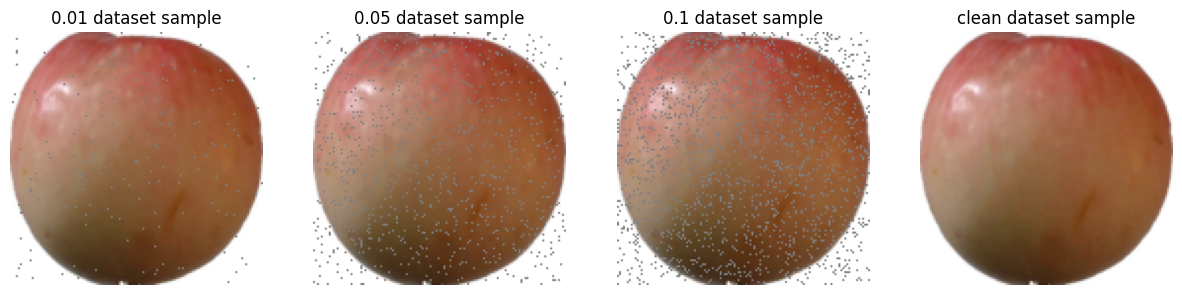

In [34]:
# Inspect datasets
fig, axs = plt.subplots(1, 4, figsize=(15,6))

# Get samples to plot
sample_num = 1
plotting_samples = {i: f[sample_num] for i, f in anomaly_test_data.items()}
plotting_samples["clean"] = clean_test_data[sample_num]
    
for idx, (frac, df) in enumerate(plotting_samples.items()):    
    img, label = df

    # Convert from [C,H,W] -> [H,W,C]
    img = img.permute(1,2,0)

    # Undo tensor normalization for plotting to avoid warning
    img = img * 0.5 + 0.5
    img = img.clamp(0,1)

    axs[idx].imshow(img)
    axs[idx].axis("off")
    axs[idx].set_title(f"{frac} dataset sample")
    
plt.show()

In [38]:
# Part 1
# with 3 different corrupted versions of the test set (1%, 5%, 10%) on best model 3
# Anomaly detection method using embeddings
def anomaly_score(test_emb, train_embs):
    """low is close to normal data, high is anomaly"""
    # Get max similarity across all training samples after matrix multiplication
    sims = test_emb @ train_embs.T
    max_sim, _ = sims.max(dim=1)

    # As a distance
    score = 1 - max_sim
    return score

In [39]:
# Load final model Task 3 for Task 4 Part 1
model3_best = EmbeddingNet2().to(device)

model_path_task3 = "task3_embedding_model_v5.pth"
checkpoint = torch.load(model_path_task3, map_location=device)
model3_best.load_state_dict(checkpoint["model_state_dict"])
model3_best.eval()
print(f"Loaded model from {model_path_task3} for Task 4 Part 1.")

Loaded model from task3_embedding_model_v5.pth for Task 4 Part 1.


In [41]:
# Get baseline on normal data
support_embs4_1, support_labs4_1 = extract_embeddings(model3_best, DataLoader(clean_train_data, batch_size=BATCH_SIZE, shuffle=False), device)
test_embs4_1, test_labs4_1 = extract_embeddings(model3_best, DataLoader(clean_test_data, batch_size=BATCH_SIZE, shuffle=False), device)
    
# Anomaly detection on clean to create 10% threshold
scores = anomaly_score(test_embs4_1, support_embs4_1)
threshold = torch.quantile(scores, 0.90)

print(f"10% threshold is {threshold}.")

10% threshold is 0.000467705714982003.


In [50]:
# Get anomaly embeddings and calculate the detection rate
for frac in anomaly_frac:
    # Load anomaly dataset
    anom_loader = DataLoader(anomaly_test_data[frac], batch_size=BATCH_SIZE, shuffle=False)

    # Extract embeddings and get anomaly scores
    anom_embs, _ = extract_embeddings(model3_best, anom_loader, device)
    scores = anomaly_score(anom_embs, support_embs4_1)

    # Predict anomalies with 10% threshold and get detection rate
    # true positive rate for anomalies.
    preds = scores > threshold
    detection_rate = preds.float().mean()

    print(f"Anomaly detection rate for dataset ({int(frac*100)}%): {detection_rate:.4f}")

Anomaly detection rate for dataset (1%): 0.9709
Anomaly detection rate for dataset (5%): 1.0000
Anomaly detection rate for dataset (10%): 1.0000
